# 08 — API Client

> **Audience:** Anyone who wants to use the PBI-Scope API client for fast, shared
> database access without loading the full SequenceRetriever locally.

| | |
|---|---|
| **Prerequisites** | PBI-Scope API service running (`docker compose up api`) and database loaded (/health check successful in logs)
| **Requirements** | `pip install pbi requests pandas` |
| **Note** | Test private data are included as example. Think to remove or replace them and re-run the pipeline. |


## What this notebook covers

1. Connect to the PBI-Scope API via `APIClient`
2. Metadata queries: phage, host, phage-host, protein
3. Single sequence and genome retrieval
4. Arbitrary SQL queries
5. Comparison with direct `quick_connect()` approach

## Setup

The setup cell below prints the `pbi` package version and confirms `APIClient` is available.

In [10]:
import sys
from pathlib import Path

# Ensure pbi package is importable
project_root = Path.cwd().parent
if str(project_root / 'src') not in sys.path:
    sys.path.insert(0, str(project_root / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pbi
from pbi import APIClient

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 20)

print(f"pbi version: {pbi.__version__}")
print(f"APIClient available: {hasattr(pbi, 'APIClient')}")

pbi version: 0.6.0
APIClient available: True


## 1. Connect to the API

The `APIClient` communicates with the PBI-Scope API service over HTTP.
Make sure the API is running: `docker compose up -d api`.

<div class="alert alert-block alert-warning"><b>PATIENCE</b>: Just like the retriever, the API needs time at startup. Plan 10-20 minutes so the API can load the sequencese”.
</div>

In [11]:
# Adjust the URL if the API is running elsewhere
# Inside Docker: http://pbi-api:8000
# Outside Docker: http://localhost:8000
import os
API_URL = os.getenv("PBI_API_URL", "http://pbi-api:8000")

client = APIClient(API_URL)

# Health check
health = client.health()
print(f"API health: {health}")

API health: {'status': 'healthy', 'database_connected': True, 'blast_available': False}


In [12]:
# Database statistics
stats = client.get_stats()
print("Database statistics:")
for key, value in stats.items():
    print(f"  {key}: {value}")

Database statistics:
  database: {'phages': 1350641, 'proteins': 71971209, 'hosts': 5527, 'phage_host_associations': 1243936, 'source_breakdown': [{'source_type': 'private', 'Source_DB': 'test_private', 'count': 5}, {'source_type': 'public', 'Source_DB': 'MetaVR', 'count': 225269}, {'source_type': 'public', 'Source_DB': 'GOV2', 'count': 195699}, {'source_type': 'public', 'Source_DB': 'MGV', 'count': 189680}, {'source_type': 'public', 'Source_DB': 'IMGVR', 'count': 177361}, {'source_type': 'public', 'Source_DB': 'GPD', 'count': 142809}, {'source_type': 'public', 'Source_DB': 'TemPhD', 'count': 66823}, {'source_type': 'public', 'Source_DB': 'ELGV', 'count': 56716}, {'source_type': 'public', 'Source_DB': 'CHVD', 'count': 44935}, {'source_type': 'public', 'Source_DB': 'URPC', 'count': 44633}, {'source_type': 'public', 'Source_DB': 'TYMEFLIES', 'count': 44192}, {'source_type': 'public', 'Source_DB': 'OVD', 'count': 37184}, {'source_type': 'public', 'Source_DB': 'GVD', 'count': 31402}, {'sou

## 2. Metadata Queries

### 2.1 Phage Metadata

In [13]:
# Get all phage metadata (limited)
phage_meta = client.get_phage_metadata(limit=100)
print(f"Phage metadata: {len(phage_meta)} rows")
phage_meta.head()

Phage metadata: 100 rows


,Phage_ID,Source_DB,Length,GC_content,Taxonomy,Completeness,Host,Lifestyle,Cluster,Subcluster
0,NC_001330.1,RefSeq,6087,45.178249,Microviridae,High-quality,Escherichia coli,virulent,cluster_158413,subcluster_199459
1,NC_001331.1,RefSeq,7349,61.491359,Inoviridae,Low-quality,Pseudomonas aeruginosa,temperate,cluster_67555,subcluster_85085
2,NC_001332.1,RefSeq,6744,42.719454,Inoviridae,Medium-quality,Escherichia coli,virulent,cluster_63254,subcluster_79716
3,NC_001335.1,RefSeq,52297,62.257873,Caudovirales,High-quality,Mycobacterium smegmatis,temperate,cluster_272329,subcluster_342024
4,NC_001341.1,RefSeq,4491,33.288800,None,Not-determined,Acholeplasma laidlawii,virulent,cluster_229441,subcluster_288779


In [14]:
# Filtered query
refseq_phages = client.get_phage_metadata(
    where_clause="Source_DB = 'RefSeq' AND Length > 50000",
    limit=50
)
print(f"RefSeq phages >50kb: {len(refseq_phages)} rows")
refseq_phages.head()

RefSeq phages >50kb: 50 rows


,Phage_ID,Source_DB,Length,GC_content,Taxonomy,Completeness,Host,Lifestyle,Cluster,Subcluster
0,NC_001335.1,RefSeq,52297,62.257873,Caudovirales,High-quality,Mycobacterium smegmatis,temperate,cluster_272329,subcluster_342024
1,NC_001884.1,RefSeq,134416,34.635014,Caudovirales,High-quality,Bacillus subtilis,temperate,cluster_8044,subcluster_10000
2,NC_000924.1,RefSeq,61670,49.367602,Caudovirales,High-quality,Escherichia coli,temperate,cluster_152435,subcluster_191866
3,NC_000902.1,RefSeq,60942,49.913032,Caudovirales,High-quality,Escherichia coli,temperate,cluster_152435,subcluster_191867
4,NC_002656.1,RefSeq,50550,63.649852,Caudovirales,High-quality,Mycobacterium smegmatis,temperate,cluster_8045,subcluster_10001


### 2.2 Host Metadata

In [15]:
try:
    host_meta = client.get_host_metadata(limit=50)
    print(f"Host metadata: {len(host_meta)} rows")
    print(host_meta.head())
except Exception as e:
    print(f"Host metadata not available: {e}")
    print("Run the host genome download workflow first.")

Host metadata: 50 rows
           Host_ID                Species_Name Strain_Name Assembly_Accession  \
0  GCF_055959565_1          Xylella fastidiosa           -    GCF_055959565.1   
1  GCF_055583525_1     Corynebacterium xerosis           -    GCF_055583525.1   
2  GCF_060284855_1         Salmonella enterica           -    GCF_060284855.1   
3  GCF_059135435_1             Bacillus cereus           -    GCF_059135435.1   
4  GCF_051904065_1  Parabacteroides distasonis           -    GCF_051904065.1   

  Assembly_Name   Assembly_Level  Genome_Length  GC_Content RefSeq_Category  \
0  ASM5595956v1  Complete Genome        2619904       52.09              na   
1  ASM5558352v1         Scaffold        2708450       69.60              na   
2  ASM6028485v1  Complete Genome        4725319       52.25              na   
3  ASM5913543v1  Complete Genome        5789343       35.08              na   
4  ASM5190406v1  Complete Genome        5163018       45.09              na   

  Download_Date

### 2.3 Phage-Host Metadata

In [16]:
try:
    pairs_meta = client.get_phage_host_metadata(limit=50)
    print(f"Phage-host pairs: {len(pairs_meta)} rows")
    print(pairs_meta.head())
except Exception as e:
    print(f"Phage-host metadata not available: {e}")

Phage-host pairs: 50 rows
      Phage_ID          Host_ID Phage_Source Phage_Source_Type  Phage_Length  \
0  uvig_307725  GCF_051861815_1          GPD            public         82443   
1  uvig_307989  GCF_041085325_1          GPD            public         55516   
2  uvig_308313  GCF_042854315_1          GPD            public         14106   
3  uvig_308416  GCF_052659795_1          GPD            public         26059   
4  uvig_308697  GCF_042850025_1          GPD            public         27642   

    Phage_GC Phage_Taxonomy Phage_Completeness Phage_Lifestyle  \
0  35.543345   Caudovirales        Low-quality        virulent   
1  56.821457   Caudovirales     Medium-quality       temperate   
2  60.839359   Caudovirales        Low-quality        virulent   
3  60.136613   Caudovirales        Low-quality       temperate   
4  40.742349   Caudovirales        Low-quality       temperate   

    Phage_Cluster   Phage_Subcluster                      Host_Species  \
0  cluster_273218  sub

### 2.4 Protein Metadata

In [17]:
try:
    protein_meta = client.get_protein_metadata(limit=50)
    print(f"Protein metadata: {len(protein_meta)} rows")
    print(protein_meta.head())
except Exception as e:
    print(f"Protein metadata error: {e}")

Protein metadata: 50 rows
    Protein_ID     Phage_ID Source_DB Protein_source  \
0  NP_039590.1  NC_001330.1    RefSeq         RefSeq   
1  NP_039591.1  NC_001330.1    RefSeq         RefSeq   
2  NP_039592.1  NC_001330.1    RefSeq         RefSeq   
3  NP_039593.1  NC_001330.1    RefSeq         RefSeq   
4  NP_039594.1  NC_001330.1    RefSeq         RefSeq   

  Function_prediction_source  Start  Stop Strand  \
0                     RefSeq    759  2243      +   
1                     RefSeq   1805  2158      +   
2                     RefSeq   2158  2319      +   
3                     RefSeq   2270  2476      +   
4                     RefSeq   2503  2955      +   

                          Product Protein_classification  
0  replication initiation protein           replication;  
1    internal scaffolding protein              assembly;  
2            hypothetical protein          hypothetical;  
3          DNA maturation protein             infection;  
4    external scaffolding pro

## 3. Sequence Retrieval

In [18]:
# Single phage sequence
phage_id = refseq_phages["Phage_ID"].iloc[0] if len(refseq_phages) > 0 else "NC_001330.1"
seq = client.get_phage_sequence(phage_id)
if seq:
    print(f">{phage_id}")
    print(f"Length: {len(seq):,} bp")
    print(f"First 100 bp: {seq[:100]}...")
else:
    print(f"Sequence not found for {phage_id}")

>NC_001335.1
Length: 52,297 bp
First 100 bp: GGTCGGTTATGCGGCCGAGCCATCCTGTACGGGTTTCCAAGTCGATCAGAGGTAGGGGCCGGCACAGAAACCACTCACATCAGGGCTGTGCGCCTCCAGG...


## 4. Genome Retrieval

In [19]:
# Phage genome (concatenated)
genome = client.get_phage_genome(phage_id, mode="concat")
if genome:
    print(f">{phage_id} (concat)")
    print(f"Length: {len(genome):,} bp")
else:
    print(f"Genome not found for {phage_id}")

>NC_001335.1 (concat)
Length: 52,297 bp


In [20]:
# Host genome stats
if len(host_meta) > 0:
    host_id = host_meta["Host_ID"].iloc[0]
    h_stats = client.get_host_genome_stats(host_id)
    print(f"Host genome stats for {host_id}:")
    if h_stats:
        for k, v in h_stats.items():
            print(f"  {k}: {v}")
    else:
        print("  No stats available")
else:
    print("No host data available")

Host genome stats for GCF_055959565_1:
  contig_count: 1
  lengths: [2619904]
  total_length: 2619904


## 5. Arbitrary SQL Queries

In [21]:
# Source database distribution
source_dist = client.query("""
    SELECT
        Source_DB,
        COUNT(*) AS phage_count,
        ROUND(AVG(Length), 0) AS avg_length,
        ROUND(AVG(GC_content), 2) AS avg_gc
    FROM fact_phages
    GROUP BY Source_DB
    ORDER BY phage_count DESC
""")
print("Source database distribution:")
source_dist

Source database distribution:


,Source_DB,phage_count,avg_length,avg_gc
0,MetaVR,225269,49253.0,47.38
1,GOV2,195699,21558.0,39.45
2,MGV,189680,46411.0,45.01
3,IMGVR,177361,49135.0,46.61
4,GPD,142809,37586.0,44.00
...,...,...,...,...
22,SVD,2634,31471.0,44.88
23,Genbank,2086,72232.0,47.52
24,DDBJ,290,41812.0,40.46
25,EMBL,156,55794.0,46.98


In [22]:
# Lifestyle distribution
lifestyle = client.query("""
    SELECT
        COALESCE(Lifestyle, 'Unknown') AS Lifestyle,
        COUNT(*) AS count
    FROM fact_phages
    GROUP BY Lifestyle
    ORDER BY count DESC
""")
print("Lifestyle distribution:")
lifestyle

Lifestyle distribution:


,Lifestyle,count
0,virulent,843899
1,temperate,500479
2,-,5807
3,filtered,456


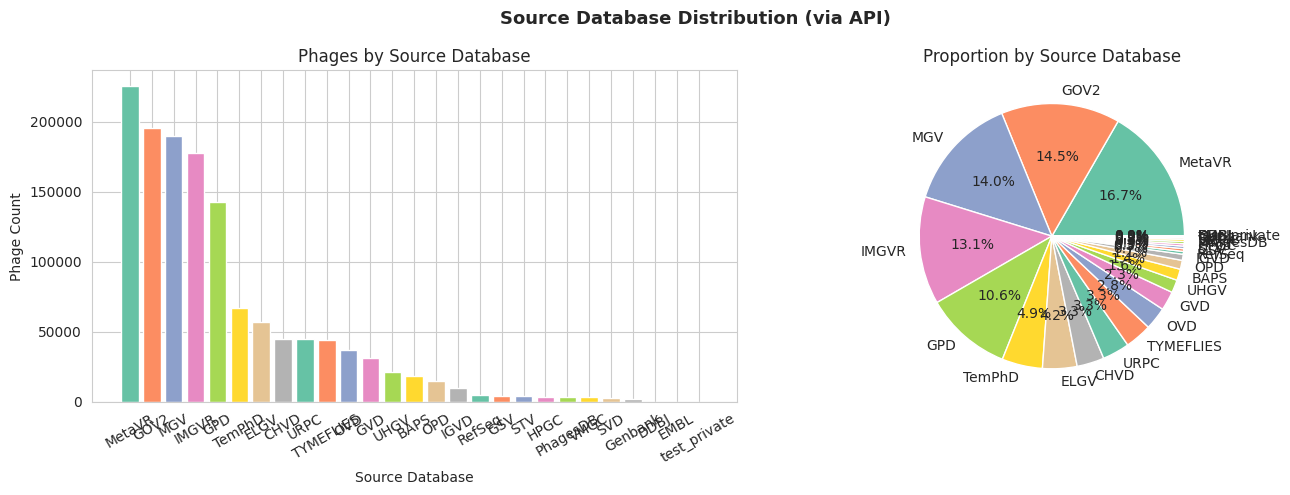

In [23]:
# Visualize source distribution
if len(source_dist) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(source_dist["Source_DB"], source_dist["phage_count"],
                color=sns.color_palette("Set2", len(source_dist)))
    axes[0].set_xlabel("Source Database")
    axes[0].set_ylabel("Phage Count")
    axes[0].set_title("Phages by Source Database")
    axes[0].tick_params(axis="x", rotation=30)

    axes[1].pie(source_dist["phage_count"], labels=source_dist["Source_DB"],
                autopct="%1.1f%%", colors=sns.color_palette("Set2", len(source_dist)))
    axes[1].set_title("Proportion by Source Database")

    plt.suptitle("Source Database Distribution (via API)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 6. Table Listing

In [24]:
tables = client.list_tables()
print(f"Tables and views ({len(tables)}):")
tables

Tables and views (29):


,name,type
0,amr_gene_summary,view
1,crispr_array_summary,view
2,crispr_evidence_distribution,view
3,dataset_provenance,table
4,dim_anti_crispr,table
...,...,...
24,phage_summary,view
25,pipeline_run_provenance,table
26,private_entity_attributes,table
27,private_interactions,table


## 7. Cleanup

In [25]:
client.close()
print("API client closed.")

API client closed.


---
## Summary

This notebook demonstrated the PBI-Scope REST API:

- **Connection & health** — `APIClient` setup and `/health` checks
- **Metadata queries** — phage, host, phage–host, and protein endpoints
- **Sequences & genomes** — single-sequence and multi-contig genome retrieval
- **SQL & tables** — arbitrary `SELECT` queries and table listing

For local bulk access and ML workflows, see `02_sequence_retrieval.ipynb`; for similarity search through the API, see `09_blast_search.ipynb`. Full endpoint details live in the [API Reference](../docs/api/overview.md).